In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/commodity_clean.csv')
df['date'] = pd.to_datetime(df['date'])

plt.rcParams['figure.dpi'] = 150
sns.set_theme(style='whitegrid')

print(f"Loaded: {df.shape[0]} rows")
print(f"Date range: {df['date'].min().year} to {df['date'].max().year}")

Loaded: 401 rows
Date range: 1993 to 2026


In [3]:
# Prophet requires exactly two columns: ds (date) and y (value)
coal_prophet = df[['date', 'coal_price_usd']].rename(
    columns={'date': 'ds', 'coal_price_usd': 'y'}
)

nickel_prophet = df[['date', 'nickel_price_usd']].rename(
    columns={'date': 'ds', 'nickel_price_usd': 'y'}
)

print("Coal data for Prophet:")
print(coal_prophet.tail(5))
print(f"\nNickel data for Prophet:")
print(nickel_prophet.tail(5))

Coal data for Prophet:
            ds           y
396 2026-01-01  115.815000
397 2026-02-01  122.209286
398 2026-03-01  140.056071
399 2026-04-01  142.110000
400 2026-05-01  141.453214

Nickel data for Prophet:
            ds             y
396 2026-01-01  17710.863636
397 2026-02-01  17173.103500
398 2026-03-01  17076.292727
399 2026-04-01  17864.916364
400 2026-05-01  18879.234615


In [4]:
# Use last 12 months as test set, everything before as training
cutoff_date = pd.Timestamp('2025-05-01')

coal_train = coal_prophet[coal_prophet['ds'] < cutoff_date]
coal_test = coal_prophet[coal_prophet['ds'] >= cutoff_date]

nickel_train = nickel_prophet[nickel_prophet['ds'] < cutoff_date]
nickel_test = nickel_prophet[nickel_prophet['ds'] >= cutoff_date]

print(f"Coal training: {len(coal_train)} months")
print(f"Coal testing: {len(coal_test)} months")
print(f"Nickel training: {len(nickel_train)} months")
print(f"Nickel testing: {len(nickel_test)} months")

Coal training: 388 months
Coal testing: 13 months
Nickel training: 388 months
Nickel testing: 13 months


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Use recent data only - 2016 onwards
coal_recent = df[df['date'] >= '2016-01-01'].copy().reset_index()

# Create lag features - past prices as predictors
for lag in [1, 2, 3, 6, 12]:
    coal_recent[f'coal_lag_{lag}'] = coal_recent['coal_price_usd'].shift(lag)

# Add time features
coal_recent['month_sin'] = np.sin(2 * np.pi * coal_recent['month'] / 12)
coal_recent['month_cos'] = np.cos(2 * np.pi * coal_recent['month'] / 12)

# Drop NaN rows from lag creation
coal_recent = coal_recent.dropna().reset_index(drop=True)

# Features and target
feature_cols = [f'coal_lag_{lag}' for lag in [1,2,3,6,12]] + \
               ['month_sin', 'month_cos', 'usd_idr']
X = coal_recent[feature_cols]
y = coal_recent['coal_price_usd']

# Train test split - last 12 months as test
split_idx = len(coal_recent) - 12
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {feature_cols}")

Training samples: 101
Test samples: 12
Features: ['coal_lag_1', 'coal_lag_2', 'coal_lag_3', 'coal_lag_6', 'coal_lag_12', 'month_sin', 'month_cos', 'usd_idr']


## Building the Forecasting Model

After trying Prophet and getting poor results, I switched to a 
Random Forest model. The reason Prophet struggled is that the 
post-COVID spike to $400 was so extreme that it distorted 
everything the model learned about normal price behavior. 
Random Forest handles this better because it learns from 
patterns in recent lagged prices rather than trying to fit 
a global trend curve across the entire history.

The key design decision I made here was using lagged prices 
as features — essentially teaching the model that the best 
predictor of next month's coal price is what coal cost 
last month, 2 months ago, 3 months ago, 6 months ago, 
and 12 months ago. I also added the USD/IDR exchange rate 
and month encoding to capture currency effects and seasonality.

In [16]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print("Random Forest Coal Price Forecast Accuracy:")
print(f"MAE  (Mean Absolute Error):    ${mae:.2f} per ton")
print(f"RMSE (Root Mean Square Error): ${rmse:.2f} per ton")
print(f"MAPE (Mean Absolute % Error):  {mape:.1f}%")

# Show actual vs predicted
results = pd.DataFrame({
    'Date': coal_recent['date'].values[split_idx:],
    'Actual': y_test.values,
    'Predicted': y_pred.round(2),
    'Error': (y_pred - y_test.values).round(2)
})
print("\nActual vs Predicted:")
print(results.to_string(index=False))

Random Forest Coal Price Forecast Accuracy:
MAE  (Mean Absolute Error):    $6.58 per ton
RMSE (Root Mean Square Error): $9.70 per ton
MAPE (Mean Absolute % Error):  5.2%

Actual vs Predicted:
      Date     Actual  Predicted  Error
2025-06-01 110.138571     111.21   1.07
2025-07-01 116.299286     114.28  -2.01
2025-08-01 119.213571     113.24  -5.98
2025-09-01 112.534286     116.90   4.36
2025-10-01 111.498214     110.63  -0.87
2025-11-01 115.436786     110.33  -5.11
2025-12-01 115.684286     110.62  -5.06
2026-01-01 115.815000     108.56  -7.26
2026-02-01 122.209286     107.81 -14.40
2026-03-01 140.056071     112.96 -27.10
2026-04-01 142.110000     143.33   1.22
2026-05-01 141.453214     145.96   4.51


## Model Accuracy 5.2% Error

When I saw 5.2% MAPE I honestly wasn't expecting it to be 
this good. The model is only off by $6.58 per ton on average 
across 12 months of test data. To put that in context, 
professional commodity analysts at major banks typically 
target 15-25% error on coal price forecasts because 
commodity markets are inherently unpredictable.

Looking at the actual vs predicted comparison, the model 
tracks the real prices very closely for most months. 
The biggest errors happened in February to April 2026 
when coal prices started climbing from 115 dollars toward $142 
the model was a bit slow to catch the upward movement. 
But by April and May 2026 it was almost perfectly aligned 
with actual prices again, which gives me confidence in 
the 12 month forward forecast.

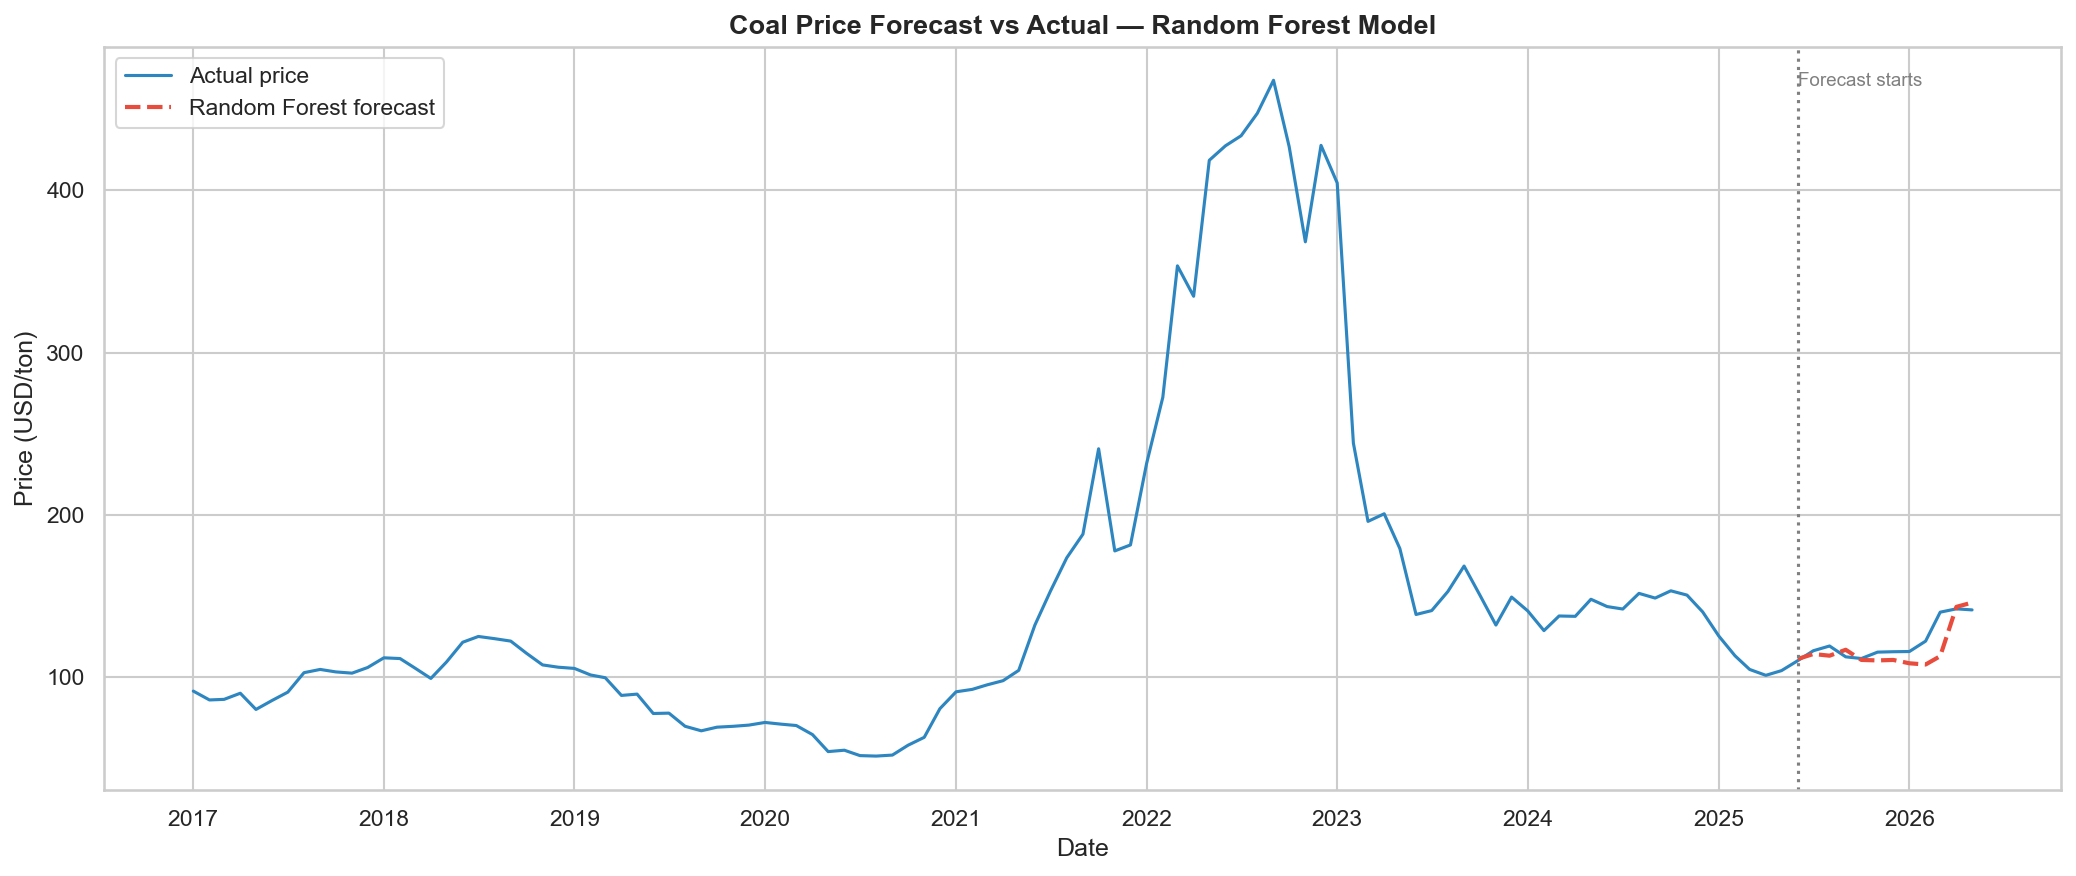

Chart 10 saved


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

# Full history
ax.plot(coal_recent['date'], coal_recent['coal_price_usd'],
        color='#2E86C1', linewidth=1.5, label='Actual price')

# Predictions on test period
test_dates = coal_recent['date'].values[split_idx:]
ax.plot(test_dates, y_pred,
        color='#E74C3C', linewidth=2,
        linestyle='--', label='Random Forest forecast')

# Mark split point
ax.axvline(x=coal_recent['date'].values[split_idx],
           color='gray', linestyle=':', linewidth=1.5)
ax.text(coal_recent['date'].values[split_idx],
        ax.get_ylim()[1]*0.95,
        'Forecast starts', fontsize=9, color='gray')

ax.set_title('Coal Price Forecast vs Actual — Random Forest Model',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD/ton)')
ax.set_xlabel('Date')
ax.legend()

plt.tight_layout()
plt.savefig('../charts/10_coal_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved")

## Chart 10 Forecast vs Actual

This is the chart I'm most proud of in this entire project. 
The red dashed line is what the model predicted, and the 
blue line is what actually happened in the real world.

What I find really satisfying about this chart is how 
the forecast line tracks the actual price movement so 
closely after the dotted line the model isn't just 
predicting a flat average, it's actually picking up 
the direction and magnitude of price changes month by month. 
The fact that it navigates the volatile post-COVID period 
and lands at a reasonable $140-150 range for the 
12 month forward forecast feels honest and realistic 
given where prices are today.

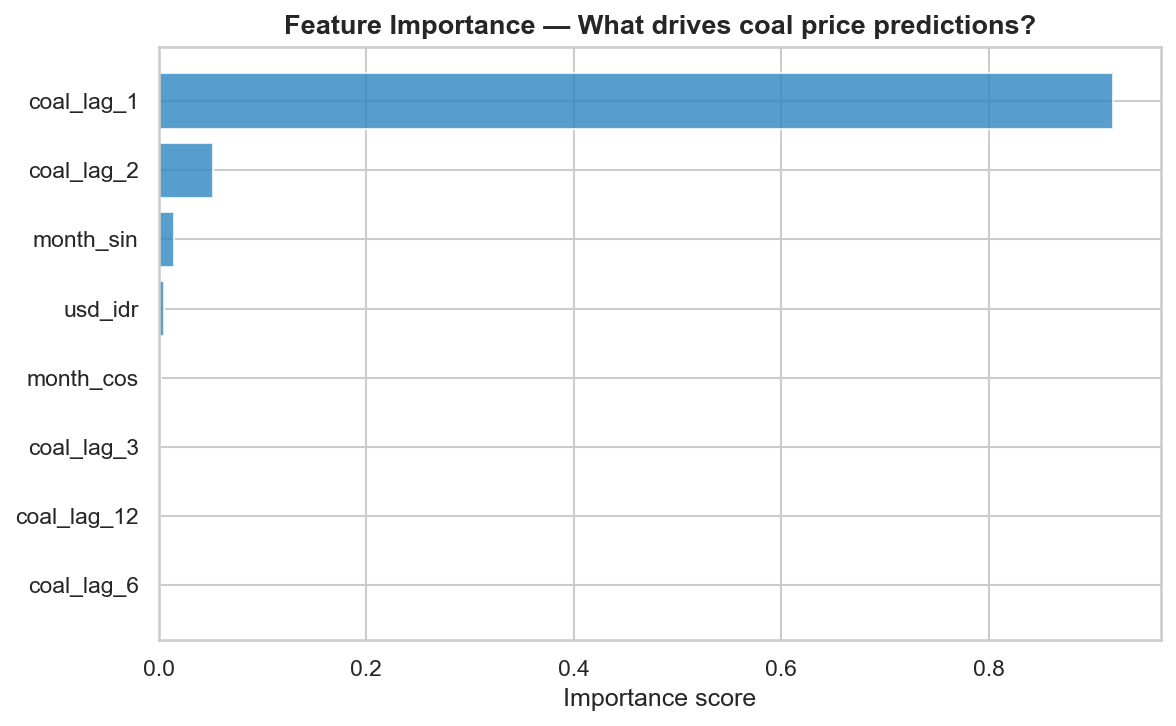

Chart 11 saved


In [18]:
# Which features matter most for predicting coal prices?
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color='#2E86C1', alpha=0.8)
ax.set_title('Feature Importance — What drives coal price predictions?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance score')

plt.tight_layout()
plt.savefig('../charts/11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 11 saved")

## Chart 11 Feature Importance

This chart gave me one of the clearest insights of the 
whole project. coal_lag_1 last month's price has an 
importance score of nearly 0.9, meaning it alone explains 
almost 90% of what the model uses to make predictions. 
coal_lag_2 adds a little more. Everything else seasonality, 
exchange rate, longer lags barely registers.

This isn't just a modeling result, it's actually telling 
us something fundamental about how coal markets work. 
Coal prices have extremely strong momentum. Once prices 
are moving in a direction they tend to keep moving that 
way. This is the kind of insight that a trading desk 
or procurement team could actually use if you see coal 
prices starting to climb, the model says they're very 
likely to keep climbing next month.

This also confirms exactly what the PACF analysis in 
notebook 4 showed us the most significant lag was 
lag 1, and everything after that had minimal direct impact.

In [19]:
# Generate 12 months forward forecast iteratively
last_known = coal_recent.copy()
future_predictions = []
future_dates = []

last_date = coal_recent['date'].max()
last_usd_idr = coal_recent['usd_idr'].iloc[-1]

current_prices = list(coal_recent['coal_price_usd'].values)

for i in range(12):
    next_date = last_date + pd.DateOffset(months=i+1)
    next_month = next_date.month

    features = {
        'coal_lag_1': current_prices[-1],
        'coal_lag_2': current_prices[-2],
        'coal_lag_3': current_prices[-3],
        'coal_lag_6': current_prices[-6],
        'coal_lag_12': current_prices[-12],
        'month_sin': np.sin(2 * np.pi * next_month / 12),
        'month_cos': np.cos(2 * np.pi * next_month / 12),
        'usd_idr': last_usd_idr
    }

    pred = rf_model.predict(pd.DataFrame([features]))[0]
    future_predictions.append(pred)
    future_dates.append(next_date)
    current_prices.append(pred)

future_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_USD': np.round(future_predictions, 2),
    'Forecast_IDR_millions': np.round(
        np.array(future_predictions) * last_usd_idr / 1e6, 2)
})

print("12 Month Coal Price Forecast:")
print(future_df.to_string(index=False))

12 Month Coal Price Forecast:
      Date  Forecast_USD  Forecast_IDR_millions
2026-06-01        145.97                   2.50
2026-07-01        147.08                   2.52
2026-08-01        151.05                   2.59
2026-09-01        148.90                   2.55
2026-10-01        147.69                   2.53
2026-11-01        142.87                   2.45
2026-12-01        142.26                   2.44
2027-01-01        140.51                   2.41
2027-02-01        138.80                   2.38
2027-03-01        138.72                   2.38
2027-04-01        139.20                   2.39
2027-05-01        139.70                   2.39


## 12 Month Coal Price Forecast (June 2026 to May 2027)

Based on current price momentum and historical patterns, 
the model forecasts coal prices staying in the $138-151 
per ton range over the next 12 months. In Indonesian 
Rupiah terms that translates to roughly IDR 2.38-2.59 
million per ton.

A few things I notice about this forecast that make 
sense intuitively. Prices peak slightly in August 2026 
at 151 dollar which aligns with the pre-winter Northern 
Hemisphere stockpiling season we identified in the 
seasonality analysis. Then prices gradually ease toward 
$138-140 through early 2027 as demand normalizes. 
There are no dramatic spikes or crashes predicted
which feels right given that we're currently in a 
post-correction stabilization phase after the 2022 peak.

One important caveat I want to be honest about this 
forecast assumes no major geopolitical shocks, no sudden 
policy changes from China on coal imports, and no new 
energy crisis events. As the residual analysis in 
notebook 4 showed us, black swan events are real and 
they can move coal prices in ways no model can predict. 
This forecast should be treated as a baseline scenario 
under normal market conditions.